<a href="https://colab.research.google.com/github/Lukas-Swc/convnet-course/blob/main/projects/03_binary_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Klasyfikator binarny - Image Classification - Drone vs. Passenger Plane

1. [Import bibliotek](#a0)
2. [Załadowanie danych](#a1)
3. [Przygotowanie zbiorów: treningowego, walidacyjnego i testowego](#a2)
4. [Eksplorcja danych](#a3)
5. [Augmentacja danych](#a4)
6. [Budowa modelu](#a5)
7. [Transfer learning - model VGG16](#a6)
8. [Transfer learning - model VGG16 - odmrożenie kilku ostatnich warstw](#a7)
9. [Ocena modelu na zbiorze testowym](#a8)
10. [Wyświetlenie błędów predykcji](#a9)

### <a name='a0'></a> Import bibliotek

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

np.set_printoptions(precision=6, suppress=True)

### <a name='a1'></a> Załadowanie danych

In [2]:
!wget https://storage.googleapis.com/esmartdata-courses-files/ann-course/flying-vehicles.zip
!unzip -q flying-vehicles.zip

--2025-07-23 16:36:34--  https://storage.googleapis.com/esmartdata-courses-files/ann-course/flying-vehicles.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.2.207, 142.250.141.207, 74.125.137.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.2.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1540232238 (1.4G) [application/x-zip-compressed]
Saving to: ‘flying-vehicles.zip’

flying-vehicles.zip 100%[===================>]   1.43G  24.9MB/s    in 61s     

2025-07-23 16:37:36 (24.3 MB/s) - ‘flying-vehicles.zip’ saved [1540232238/1540232238]



### <a name='a2'></a> Przygotowanie zbiorów: treningowego, walidacyjnego i testowego

In [51]:
!rm -rf ./images

In [52]:
base_dir = './data/planes'
raw_no_of_files = {}
classes = ['drone', 'fighter-jet', 'helicopter', 'missile', 'passenger-plane', 'rocket']
for dir in classes:
  raw_no_of_files[dir] = len(os.listdir(os.path.join(base_dir, dir)))

raw_no_of_files.items()

dict_items([('drone', 1332), ('fighter-jet', 1867), ('helicopter', 1387), ('missile', 1334), ('passenger-plane', 1424), ('rocket', 1186)])

In [53]:
data_dir = './images'

if not os.path.exists(data_dir):
  os.mkdir(data_dir)

train_dir = os.path.join(data_dir, 'train') # katalog zbioru treningowego
valid_dir = os.path.join(data_dir, 'valid') # katalog zbioru walidacyjnego
test_dir = os.path.join(data_dir, 'test')   # katalog zbioru testowego

train_drone_dir = os.path.join(train_dir, 'drone')
train_passenger_dir = os.path.join(train_dir, 'passenger')

valid_drone_dir = os.path.join(valid_dir, 'drone')
valid_passenger_dir = os.path.join(valid_dir, 'passenger')

test_drone_dir = os.path.join(test_dir, 'drone')
test_passenger_dir = os.path.join(test_dir, 'passenger')

for directory in (train_dir, valid_dir, test_dir):
  if not os.path.exists(directory):
    os.mkdir(directory)

dirs = [train_drone_dir, train_passenger_dir, valid_drone_dir, valid_passenger_dir, test_drone_dir, test_passenger_dir]

for dir in dirs:
  if not os.path.exists(dir):
    os.mkdir(dir)

In [54]:
drone_fnames = os.listdir(os.path.join(base_dir, 'drone'))
passenger_fnames = os.listdir(os.path.join(base_dir, 'passenger-plane'))

drone_fnames = [fname for fname in drone_fnames if fname.split('.')[1].lower() in ['jpg', 'png', 'jpeg']]
passenger_fnames = [fname for fname in passenger_fnames if fname.split('.')[1].lower() in ['jpg', 'png', 'jpeg']]

In [55]:
size = min(len(drone_fnames), len(passenger_fnames))

train_size = int(np.floor(0.7 * size))
valid_size = int(np.floor(0.2 * size))
test_size = size - train_size - valid_size

train_idx = train_size
valid_idx = train_size + valid_size
test_idx = train_size + valid_size + test_size

In [56]:
for i, fname in enumerate(drone_fnames):
  if i <= train_idx:
    src = os.path.join(base_dir, 'drone', fname)
    dst = os.path.join(train_drone_dir, fname)
    shutil.copyfile(src, dst)
  elif train_idx < i <= valid_idx:
    src = os.path.join(base_dir, 'drone', fname)
    dst = os.path.join(valid_drone_dir, fname)
    shutil.copyfile(src, dst)
  elif valid_idx < i < test_idx:
    src = os.path.join(base_dir, 'drone', fname)
    dst = os.path.join(test_drone_dir, fname)
    shutil.copyfile(src, dst)

for i, fname in enumerate(passenger_fnames):
  if i <= train_idx:
    src = os.path.join(base_dir, 'passenger-plane', fname)
    dst = os.path.join(train_passenger_dir, fname)
    shutil.copyfile(src, dst)
  elif train_idx < i <= valid_idx:
    src = os.path.join(base_dir, 'passenger-plane', fname)
    dst = os.path.join(valid_passenger_dir, fname)
    shutil.copyfile(src, dst)
  elif valid_idx < i < test_idx:
    src = os.path.join(base_dir, 'passenger-plane', fname)
    dst = os.path.join(test_passenger_dir, fname)
    shutil.copyfile(src, dst)


print('drone - zbior treningowy', len(os.listdir(train_drone_dir)))
print('drone - zbior walidacyjny', len(os.listdir(valid_drone_dir)))
print('drone - zbior testowy', len(os.listdir(test_drone_dir)))

print('passenger - zbior treningowy', len(os.listdir(train_passenger_dir)))
print('passenger - zbior walidacyjny', len(os.listdir(valid_passenger_dir)))
print('passenger - zbior testowy', len(os.listdir(test_passenger_dir)))

drone - zbior treningowy 919
drone - zbior walidacyjny 262
drone - zbior testowy 131
passenger - zbior treningowy 919
passenger - zbior walidacyjny 262
passenger - zbior testowy 131


### <a name='a3'></a> Eksplorcja danych

(np.float64(-0.5), np.float64(2099.5), np.float64(1499.5), np.float64(-0.5))

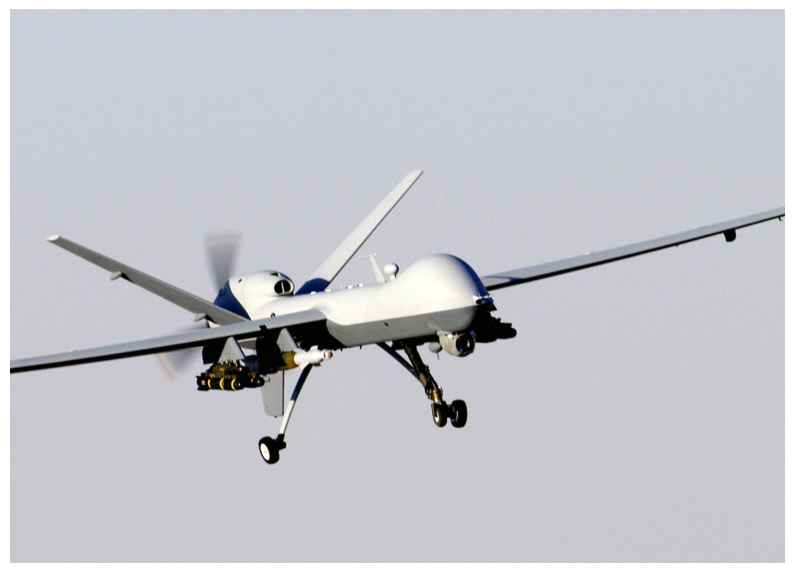

In [57]:
#@title Wybierz indeks przykladowego zdjecia drona ze zbioru treningowego:

idx = 393 #@param {type:'slider', min:0, max:919}
names_mapping = dict(enumerate(drone_fnames))
img_path = os.path.join(train_drone_dir, names_mapping[idx])

img = tf.keras.preprocessing.image.load_img(img_path)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.grid(False)
plt.axis(False)

(np.float64(-0.5), np.float64(499.5), np.float64(229.5), np.float64(-0.5))

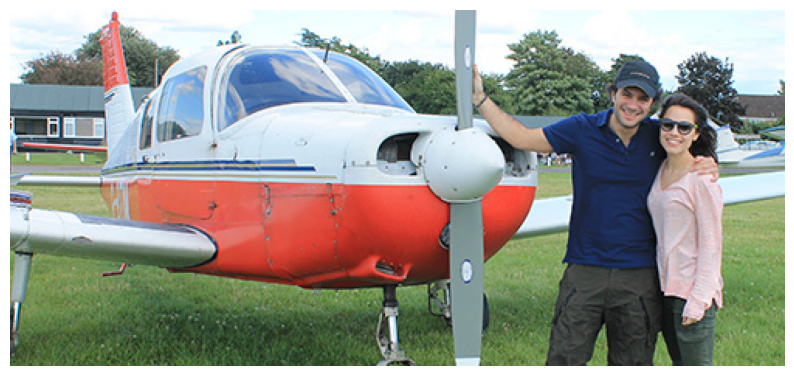

In [58]:
#@title Wybierz indeks przykladowego zdjecia samolotu pasazerskiego ze zbioru treningowego:

idx = 308 #@param {type:'slider', min:0, max:919}
names_mapping = dict(enumerate(passenger_fnames))
img_path = os.path.join(train_passenger_dir, names_mapping[idx])

img = tf.keras.preprocessing.image.load_img(img_path)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.grid(False)
plt.axis(False)

### <a name='a4'></a> Augmentcja danych

In [59]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=40,                # zakres kąta o który losowo zostanie wykonany obrót obrazów
    rescale=1./255.,
    width_shift_range=0.2,            # pionowe przekształcenia obrazu
    height_shift_range=0.2,           # poziome przekształcenia obrazu
    shear_range=0.2,                  # zares losowego przycianania obrazu
    zoom_range=0.2,                   # zakres losowego przybliżania obrazu
    horizontal_flip=True,             # losowe odbicie połowy obrazu w płaszczyźnie poziomej
    fill_mode='nearest'               # strategia wypełniania nowo utworzonych pikseli, któe mogą powstać w wyniku przekształceń
)

# przeskalowujemy wszystkie obrazy o współczynnik 1/255
valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255.)


train_generator = train_datagen.flow_from_directory(directory=train_dir,
                                                    target_size=(150, 150),
                                                    batch_size=32,
                                                    class_mode='binary')

valid_generator = valid_datagen.flow_from_directory(directory=valid_dir,
                                                    target_size=(150, 150),
                                                    batch_size=32,
                                                    class_mode='binary')

Found 1838 images belonging to 2 classes.
Found 524 images belonging to 2 classes.


In [60]:
def display_augmented_images(directory, idx):
  """
  Funkcja zwraca wykres przykladowych obrazow uzyskanych za pomoca techniki augmentacji danych.
  """
  fnames = [os.path.join(directory, fname) for fname in os.listdir(directory)]
  img_path = fnames[idx]
  img = tf.keras.preprocessing.image.load_img(img_path, target_size=(150, 150))

  x = tf.keras.preprocessing.image.img_to_array(img)
  x = x.reshape((1, ) + x.shape)

  i = 1
  plt.figure(figsize=(16, 8))
  for batch in train_datagen.flow(x, batch_size=1):
    plt.subplot(3, 4, i)
    plt.grid(False)
    imgplot = plt.imshow(tf.keras.preprocessing.image.array_to_img(batch[0]))
    i += 1
    if i % 13 == 0:
      break

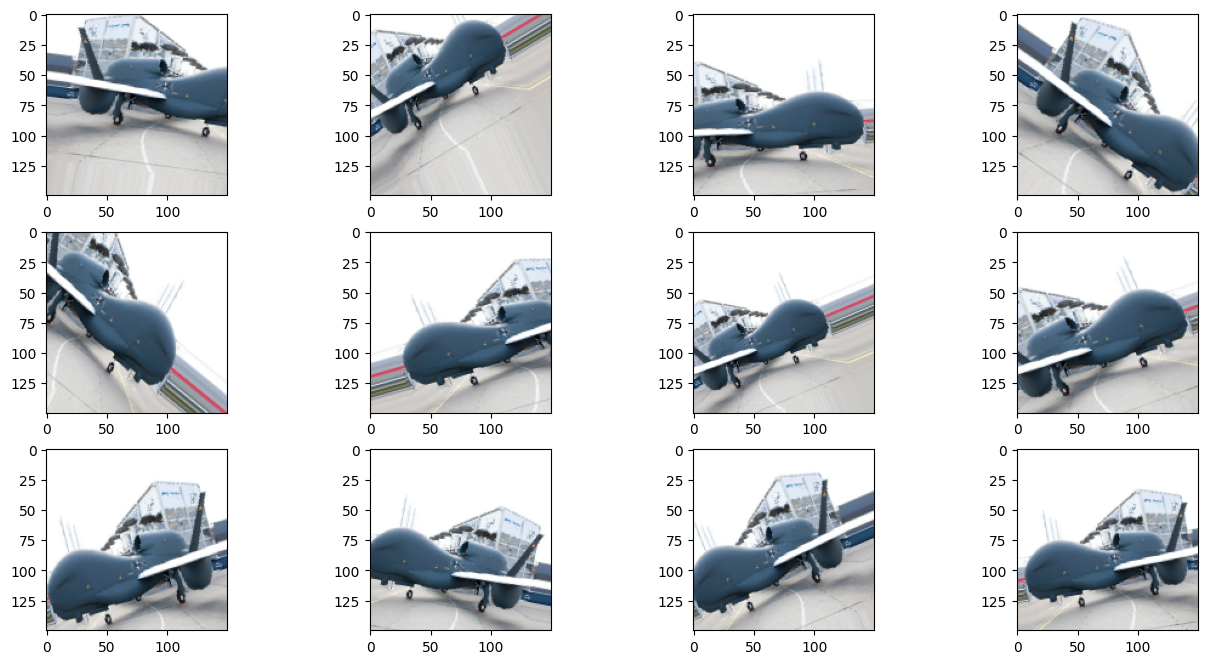

In [61]:
#@title Zbior treningowy drone:
idx = 327 #@param {type:'slider', min:0, max:919}
display_augmented_images(train_drone_dir, idx)

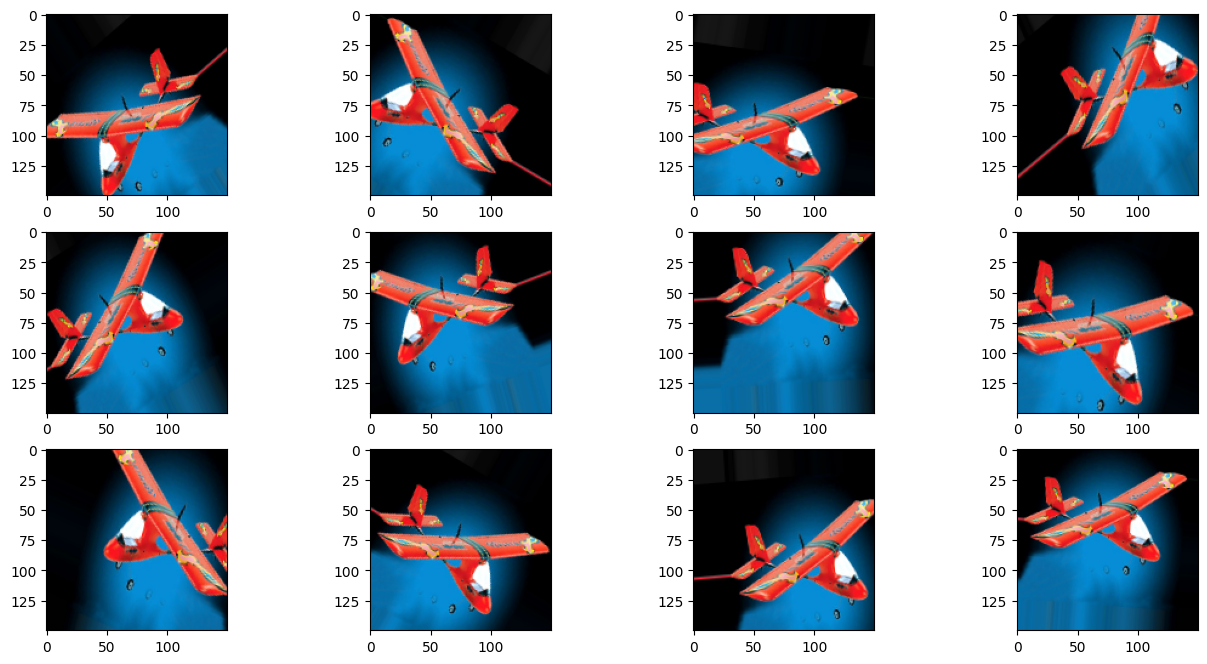

In [62]:
#@title Zbior treningowy passenger:
idx = 338 #@param {type:'slider', min:0, max:919}
display_augmented_images(train_passenger_dir, idx)

### <a name='a5'></a> Budowa modelu

In [15]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [17]:
# !rm -rf logs
# !mkdir logs

# from tensorflow.keras.callbacks import TensorBoard

# tensorboard = TensorBoard(log_dir='logs')

In [19]:
batch_size = 32
steps_per_epoch = train_size // batch_size
validation_steps = valid_size // batch_size

history = model.fit(train_generator,
                    steps_per_epoch=steps_per_epoch,
                    epochs=30,      #100
                    validation_data=valid_generator,
                    validation_steps=validation_steps)

Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 689ms/step - accuracy: 0.4918 - loss: 0.7071 - val_accuracy: 0.4531 - val_loss: 0.6954
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 497ms/step - accuracy: 0.5307 - loss: 0.6917 - val_accuracy: 0.5000 - val_loss: 0.6871
Epoch 3/30
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5625 - loss: 0.6870

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.4872 - loss: 0.6893 - val_accuracy: 0.5234 - val_loss: 0.6905
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 522ms/step - accuracy: 0.5292 - loss: 0.6888 - val_accuracy: 0.6484 - val_loss: 0.6830
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 584ms/step - accuracy: 0.5603 - loss: 0.6843 - val_accuracy: 0.6445 - val_loss: 0.6681
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.5312 - loss: 0.6911 - val_accuracy: 0.6172 - val_loss: 0.6753
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 525ms/step - accuracy: 0.5646 - loss: 0.6801 - val_accuracy: 0.5117 - val_loss: 0.7159
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 745ms/step - accuracy: 0.5155 - loss: 0.6988 - val_accuracy: 0.4570 - val_loss: 0.6908
Epoch 9/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.5647 - loss: 0.6882 - val_accuracy: 0.5586 - val_loss: 0.6845
Epoch 10/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 623ms/step - accuracy: 0.5953 - loss: 0.6602 - val_accuracy: 0.5898 - 

In [ ]:
# %load_ext tensorboard

In [ ]:
# %tensorboard --logdir logs/fit

In [63]:
def plot_hist(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=hist['epoch'], y=hist['accuracy'], name='accuracy', mode='markers+lines'))
    fig.add_trace(go.Scatter(x=hist['epoch'], y=hist['val_accuracy'], name='val_accuracy', mode='markers+lines'))
    fig.update_layout(width=1000, height=500, title='Accuracy vs. Val Accuracy', xaxis_title='Epoki', yaxis_title='Accuracy', yaxis_type='log')
    fig.show()

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=hist['epoch'], y=hist['loss'], name='loss', mode='markers+lines'))
    fig.add_trace(go.Scatter(x=hist['epoch'], y=hist['val_loss'], name='val_loss', mode='markers+lines'))
    fig.update_layout(width=1000, height=500, title='Loss vs. Val Loss', xaxis_title='Epoki', yaxis_title='Loss', yaxis_type='log')
    fig.show()

plot_hist(history)

### <a name='a6'></a> Transfer learning - model VGG16

In [21]:
conv_base = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
conv_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model = tf.keras.models.Sequential([
    conv_base,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=256, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
print(f'Liczba warstw trenowanych przed zamrozeniem {len(model.trainable_weights)}')
conv_base.trainable = False
print(f'Liczba warstw trenowanych po zamrozeniu {len(model.trainable_weights)}')

Liczba warstw trenowanych przed zamrozeniem 30
Liczba warstw trenowanych po zamrozeniu 4


In [24]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [25]:
history = model.fit(train_generator,
                    steps_per_epoch=steps_per_epoch,
                    epochs=30,      #100
                    validation_data=valid_generator,
                    validation_steps=validation_steps)

Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 601ms/step - accuracy: 0.5758 - loss: 0.7840 - val_accuracy: 0.6875 - val_loss: 0.5754
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 727ms/step - accuracy: 0.7208 - loss: 0.5294 - val_accuracy: 0.6992 - val_loss: 0.5445
Epoch 3/30
 2/28 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.7031 - loss: 0.5260

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.



28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - accuracy: 0.7176 - loss: 0.5089 - val_accuracy: 0.7070 - val_loss: 0.4981
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 46s 570ms/step - accuracy: 0.7549 - loss: 0.4926 - val_accuracy: 0.7852 - val_loss: 0.4645
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 578ms/step - accuracy: 0.7543 - loss: 0.4873 - val_accuracy: 0.7656 - val_loss: 0.4900
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - accuracy: 0.7824 - loss: 0.4042 - val_accuracy: 0.7617 - val_loss: 0.5001
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 574ms/step - accuracy: 0.7512 - loss: 0.4751 - val_accuracy: 0.7539 - val_loss: 0.5290
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 729ms/step - accuracy: 0.7543 - loss: 0.4985 - val_accuracy: 0.7305 - val_loss: 0.5232
Epoch 9/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 0.7467 - loss: 0.4606 - val_accuracy: 0.7617 - val_loss: 0.4471
Epoch 10/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 705ms/step - accuracy: 0.7814 - loss: 0.4494 - val_accuracy: 0.7656 

In [26]:
import plotly.graph_objects as go
plot_hist(history)

### <a name='a7'></a> Transfer learning - model VGG16 - odmrożenie kilku ostatnich warstw

In [64]:
conv_base = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
conv_base.trainable = True

def print_layers(model):
  for layer in model.layers:
    print(f'layer_name: {layer.name:13} trainable: {layer.trainable}')

print_layers(conv_base)

layer_name: input_layer_5 trainable: True
layer_name: block1_conv1  trainable: True
layer_name: block1_conv2  trainable: True
layer_name: block1_pool   trainable: True
layer_name: block2_conv1  trainable: True
layer_name: block2_conv2  trainable: True
layer_name: block2_pool   trainable: True
layer_name: block3_conv1  trainable: True
layer_name: block3_conv2  trainable: True
layer_name: block3_conv3  trainable: True
layer_name: block3_pool   trainable: True
layer_name: block4_conv1  trainable: True
layer_name: block4_conv2  trainable: True
layer_name: block4_conv3  trainable: True
layer_name: block4_pool   trainable: True
layer_name: block5_conv1  trainable: True
layer_name: block5_conv2  trainable: True
layer_name: block5_conv3  trainable: True
layer_name: block5_pool   trainable: True


In [65]:
set_trainable = False
for layer in conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False

print_layers(conv_base)

layer_name: input_layer_5 trainable: False
layer_name: block1_conv1  trainable: False
layer_name: block1_conv2  trainable: False
layer_name: block1_pool   trainable: False
layer_name: block2_conv1  trainable: False
layer_name: block2_conv2  trainable: False
layer_name: block2_pool   trainable: False
layer_name: block3_conv1  trainable: False
layer_name: block3_conv2  trainable: False
layer_name: block3_conv3  trainable: False
layer_name: block3_pool   trainable: False
layer_name: block4_conv1  trainable: False
layer_name: block4_conv2  trainable: False
layer_name: block4_conv3  trainable: False
layer_name: block4_pool   trainable: False
layer_name: block5_conv1  trainable: True
layer_name: block5_conv2  trainable: True
layer_name: block5_conv3  trainable: True
layer_name: block5_pool   trainable: True


In [66]:
model = tf.keras.models.Sequential([
    conv_base,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=256, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 9,177,089 (35.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [105]:
history = model.fit(train_generator,
                    steps_per_epoch=steps_per_epoch,
                    epochs=20,      #100
                    validation_data=valid_generator,
                    validation_steps=validation_steps)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 600ms/step - accuracy: 0.8690 - loss: 0.3226 - val_accuracy: 0.8203 - val_loss: 0.3766
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 763ms/step - accuracy: 0.8642 - loss: 0.3206 - val_accuracy: 0.8516 - val_loss: 0.3490
Epoch 3/20
 2/28 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.8828 - loss: 0.2892

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.



28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.8901 - loss: 0.2837 - val_accuracy: 0.7695 - val_loss: 0.4398
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 695ms/step - accuracy: 0.8331 - loss: 0.3468 - val_accuracy: 0.8125 - val_loss: 0.3944
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 547ms/step - accuracy: 0.8462 - loss: 0.3429 - val_accuracy: 0.8086 - val_loss: 0.3869
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.7684 - loss: 0.4155 - val_accuracy: 0.8125 - val_loss: 0.3812
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 564ms/step - accuracy: 0.8403 - loss: 0.3426 - val_accuracy: 0.8555 - val_loss: 0.3445
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 565ms/step - accuracy: 0.8368 - loss: 0.3247 - val_accuracy: 0.8242 - val_loss: 0.3625
Epoch 9/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - accuracy: 0.7651 - loss: 0.4811 - val_accuracy: 0.8164 - val_loss: 0.3665
Epoch 10/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 574ms/step - accuracy: 0.8536 - loss: 0.3101 - val_accuracy: 0.8047 

In [106]:
plot_hist(history)

### <a name='a8'></a> Ocena modelu na zbiorze testowym

In [107]:
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255.)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

y_prob = model.predict(test_generator, test_generator.samples)
y_prob = y_prob.ravel()
y_prob

Found 219 images belonging to 2 classes.
  4/219 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step 

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step


array([0.000339, 0.026682, 0.000137, 0.000643, 0.000234, 0.00871 ,
       0.000272, 0.061881, 0.000207, 0.02767 , 0.003928, 0.000106,
       0.000033, 0.001919, 0.001853, 0.076203, 0.261952, 0.000032,
       0.021857, 0.001217, 0.000792, 0.000019, 0.000173, 0.000654,
       0.007232, 0.004975, 0.044416, 0.000583, 0.034114, 0.042701,
       0.307375, 0.003515, 0.519072, 0.212982, 0.002128, 0.018998,
       0.000116, 0.171506, 0.017828, 0.000234, 0.003184, 0.018245,
       0.002003, 0.178367, 0.055102, 0.016632, 0.030388, 0.000466,
       0.043178, 0.012892, 0.001983, 0.021051, 0.001375, 0.010778,
       0.059713, 0.00014 , 0.070871, 0.227648, 0.01418 , 0.001292,
       0.116135, 0.00232 , 0.05231 , 0.091901, 0.039591, 0.322154,
       0.136612, 0.210106, 0.021294, 0.008383, 0.152458, 0.470678,
       0.517501, 0.249429, 0.000032, 0.007839, 0.034311, 0.008993,
       0.261584, 0.000148, 0.000007, 0.150355, 0.057434, 0.083593,
       0.049155, 0.082715, 0.359709, 0.142856, 0.190793, 0.044

In [108]:
predictions = pd.DataFrame({'y_prob': y_prob})
predictions['class'] = predictions['y_prob'].apply(lambda x: 1 if x > 0.5 else 0)
predictions

,y_prob,class
0,0.000339,0
1,0.026682,0
2,0.000137,0
3,0.000643,0
4,0.000234,0
...,...,...
214,0.574447,1
215,0.984964,1
216,0.358226,0
217,0.873977,1


In [109]:
y_true = test_generator.classes
y_true

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int32)

In [110]:
y_pred = predictions['class'].values
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1])

In [111]:
test_generator.class_indices

{'drone': 0, 'passenger': 1}

In [112]:
cm = confusion_matrix(y_true, y_pred)
cm

array([[102,   2],
       [  8, 107]])

In [113]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       104
           1       0.98      0.93      0.96       115

    accuracy                           0.95       219
   macro avg       0.95      0.96      0.95       219
weighted avg       0.96      0.95      0.95       219



### <a name='a9'></a> Wyświetlenie błędów predykcji

In [114]:
errors = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred}, index=test_generator.filenames)
errors

,y_true,y_pred
drone/00000010.jpg,0,0
drone/00000033.jpg,0,0
drone/00000037.jpg,0,0
drone/00000046.jpg,0,0
drone/00000048.jpg,0,0
...,...,...
passenger/00001414.jpg,1,1
passenger/00001424.jpg,1,1
passenger/00001438.jpg,1,0
passenger/00001444.jpg,1,1


In [115]:
errors['is_incorect'] = (errors['y_true'] != errors['y_pred']) * 1
errors

,y_true,y_pred,is_incorect
drone/00000010.jpg,0,0,0
drone/00000033.jpg,0,0,0
drone/00000037.jpg,0,0,0
drone/00000046.jpg,0,0,0
drone/00000048.jpg,0,0,0
...,...,...,...
passenger/00001414.jpg,1,1,0
passenger/00001424.jpg,1,1,0
passenger/00001438.jpg,1,0,1
passenger/00001444.jpg,1,1,0


In [116]:
errors[errors['is_incorect'] == 1].index

Index(['drone/00000379.png', 'drone/00000865.png', 'passenger/00000156.jpg',
       'passenger/00000270.jpg', 'passenger/00000388.jpg',
       'passenger/00000580.jpg', 'passenger/00000583.jpg',
       'passenger/00001062.jpg', 'passenger/00001144.jpg',
       'passenger/00001438.jpg'],
      dtype='object')

(np.float64(-0.5), np.float64(799.5), np.float64(499.5), np.float64(-0.5))

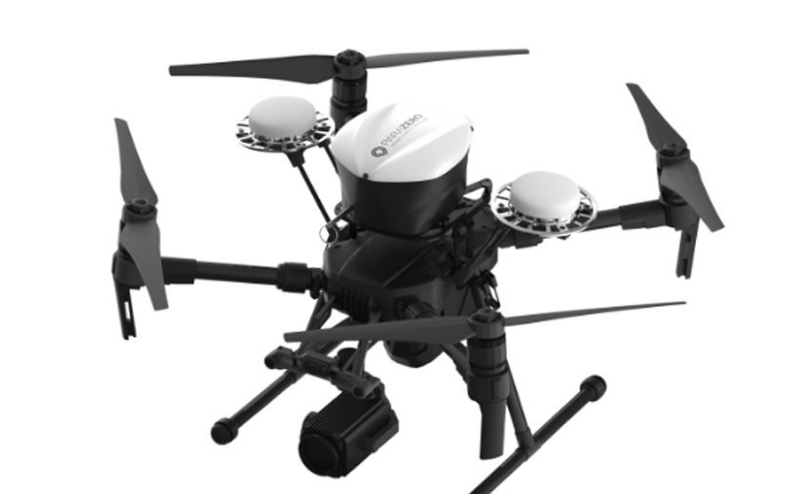

In [118]:
img_path = os.path.join(test_drone_dir, '00000156.jpg')

img = tf.keras.preprocessing.image.load_img(img_path)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.grid(False)
plt.axis(False)

In [120]:
errors[errors['is_incorect'] == 1].index

Index(['drone/00000379.png', 'drone/00000865.png', 'passenger/00000156.jpg',
       'passenger/00000270.jpg', 'passenger/00000388.jpg',
       'passenger/00000580.jpg', 'passenger/00000583.jpg',
       'passenger/00001062.jpg', 'passenger/00001144.jpg',
       'passenger/00001438.jpg'],
      dtype='object')

(np.float64(-0.5), np.float64(1023.5), np.float64(744.5), np.float64(-0.5))

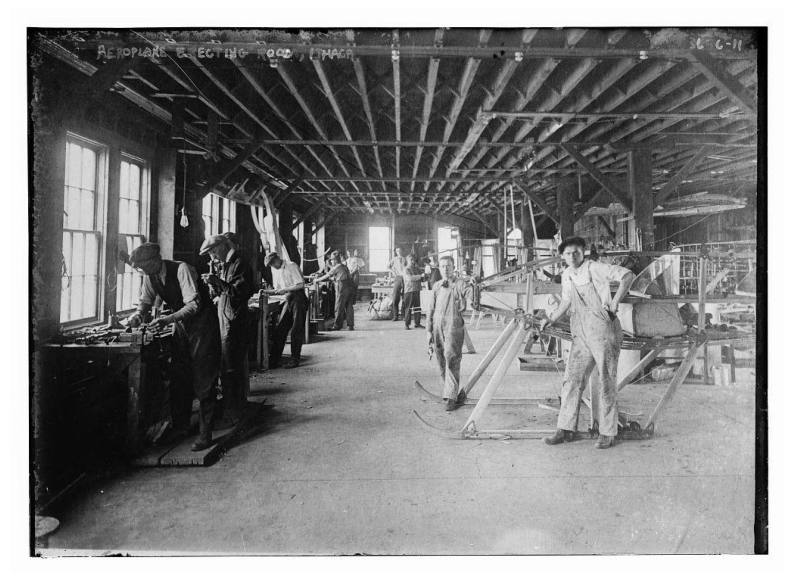

In [121]:
img_path = os.path.join(test_passenger_dir, '00000580.jpg')

img = tf.keras.preprocessing.image.load_img(img_path)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.grid(False)
plt.axis(False)

In [82]:
remove_errors = errors[errors['is_incorect'] == 1].index

###Usuwanie blednie sklasyfikowanych zdjec

In [86]:
#for filename in remove_errors:
#  file_path = os.path.join(test_dir, filename)
#  if os.path.isfile(file_path):
#    os.remove(file_path)
#    print(f"Usunięto plik: {file_path}")

Usunięto plik: ./images/test/drone/00000193.jpeg
Usunięto plik: ./images/test/drone/00000236.jpg
Usunięto plik: ./images/test/drone/00000270.jpg
Usunięto plik: ./images/test/drone/00000373.jpg
Usunięto plik: ./images/test/drone/00000377.jpg
Usunięto plik: ./images/test/drone/00000535.jpg
Usunięto plik: ./images/test/drone/00000598.jpg
Usunięto plik: ./images/test/drone/00000616.jpg
Usunięto plik: ./images/test/drone/00000680.jpg
Usunięto plik: ./images/test/drone/00000745.jpg
Usunięto plik: ./images/test/drone/00000786.jpg
Usunięto plik: ./images/test/drone/00000819.jpg
Usunięto plik: ./images/test/drone/00000916.jpg
Usunięto plik: ./images/test/drone/00000919.jpg
Usunięto plik: ./images/test/drone/00000940.jpg
Usunięto plik: ./images/test/drone/00001011.jpg
Usunięto plik: ./images/test/drone/00001014.jpg
Usunięto plik: ./images/test/drone/00001060.jpg
Usunięto plik: ./images/test/drone/00001092.png
Usunięto plik: ./images/test/drone/00001155.jpg
Usunięto plik: ./images/test/drone/0000